In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D


In [3]:
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [4]:
x_train.shape

(60000, 28, 28)

y_train[0]: 5


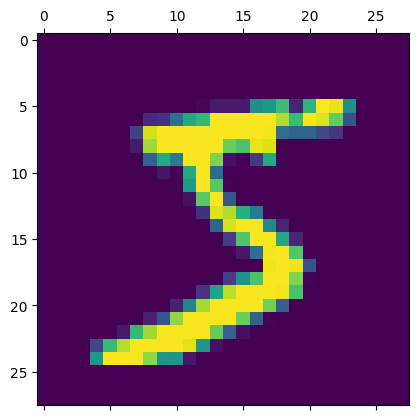

In [5]:
plt.matshow(x_train[0])
print('y_train[0]:',y_train[0])
plt.show()

# Preprocessing

In [6]:
#normalizing 
x_train_normalized = x_train / 255.0
x_test_normalized = x_test / 255.0

In [7]:
#resizing the data
x_trainr = x_train_normalized.reshape(60000, 28, 28, 1)#adding 1 dimension for color channel
x_testr = x_test_normalized.reshape(10000, 28, 28, 1)#1=grayscale ,3=RGB

In [8]:
x_trainr.shape

(60000, 28, 28, 1)

# CNN model

convulutions scans the image and finds features or patterns or filters, in our case 3x3 matrix,
output size=(N-F+1)


In [9]:
model=keras.Sequential()

#1st convlutional layer
model.add(Conv2D(32,(3,3),input_shape=(28,28,1),activation='relu'))#32 feature detectors of 3x3 size (filters or kernels) output size = 26x26x32
model.add(MaxPooling2D(pool_size=(2,2)))

#2nd convulational layer
model.add(Conv2D(64,(3,3),activation='relu'))#output size = 11x11x64 ;that is 64 filters and 64 feature maps
model.add(MaxPooling2D(pool_size=(2,2)))

#3rd convulational layer
model.add(Conv2D(128,(3,3),activation='relu'))#output size = 3x3x128 ;that is 128 filters and 128 feature maps



#flatten
model.add(Flatten())

#fully connected layer
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax')) # 10 classes/neurons for digits 0-9





d:\data science 2025\git_repository\data-science-project-\digit_recognization_CNN\demo\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,162 (973.29 KB)

 Trainable params: 249,162 (973.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
model.fit(x_trainr,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.9557 - loss: 0.1375
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9869 - loss: 0.0445
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9898 - loss: 0.0331
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9918 - loss: 0.0253
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9937 - loss: 0.0203


In [16]:
model.evaluate(x_testr,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9905 - loss: 0.0311


[0.031135287135839462, 0.9904999732971191]

In [13]:
y_pred=model.predict(x_testr)
y_pred_labels=np.argmax(y_pred,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [14]:
print(y_pred.shape)
y_pred_labels[:5]

(10000, 10)


array([7, 2, 1, 0, 4])

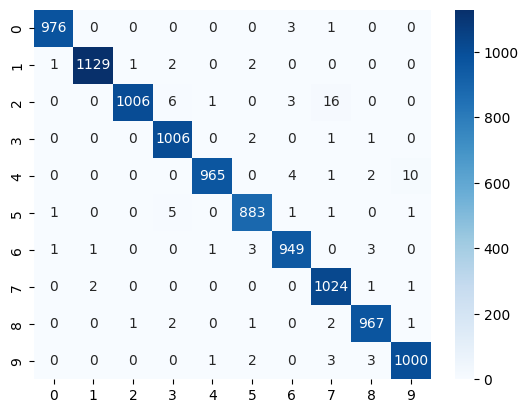

In [15]:
cm=tf.math.confusion_matrix(y_test, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.show()

In [17]:
#saving the model
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(model,f)